In [1]:
#from cme.diffusion_models import diffusion as dd
from cme.diffusion_models import diffusion_likelihood as dd
#from cme.diffusion_models import diffusion_discrete as dd
import pandas as pd
import numpy as np
from cme.utils import common_utils as ut
import arviz as az
import os

In [2]:
from IPython.display import clear_output, DisplayHandle
def update_patch(self, obj):
    clear_output(wait=True)
    self.display(obj)
DisplayHandle.update = update_patch

In [3]:
import pymc
pymc.__version__

'5.4.0'

In [4]:
#from jax.lib import xla_bridge
#print(xla_bridge.get_backend().platform)

In [5]:
#rotation_RT = pd.read_csv(f"data/final_project_rt.csv")
rotation_RT = pd.read_csv(f"data/RT_congr8_11_v2_1.csv").iloc[0:100,:]
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]


#rotation_X = pd.read_csv(f"data/final_project_ra.csv")
rotation_X = pd.read_csv(f"data/X_congr8_11_v2_1.csv").iloc[0:100,:]
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [6]:
rotation_RT_n.shape

(98, 12)

In [7]:
rotation_RT_n

array([[0.635027, 0.485902, 0.686937, ..., 1.084598, 0.389313, 0.513651],
       [0.606198, 0.500256, 0.542234, ..., 0.578486, 0.611492, 0.516346],
       [0.799611, 0.741095, 0.630571, ..., 0.711959, 0.702859, 0.728361],
       ...,
       [1.320017, 0.717044, 0.60321 , ..., 0.749351, 0.765282, 0.85765 ],
       [0.678569, 0.737655, 0.596415, ..., 1.036446, 0.764211, 0.818281],
       [0.833624, 1.177578, 1.075732, ..., 0.765133, 1.310112, 0.740976]])

In [8]:
samples_n, tune, chains, acceptance_rate = 12500, 7000, 4, 0.95

#posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
#samples_n,chains=chains, sampler="PYMC", tune=tune, acceptance_rate = acceptance_rate)

posterior_chain = dd.sample_posterior_params(rotation_RT_n, rotation_X_n,num_warmup=tune,
                                             samples_n=samples_n,target_accept_prob=acceptance_rate)


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


  0%|          | 0/19500 [00:00<?, ?it/s]

  0%|          | 0/19500 [00:00<?, ?it/s]

  0%|          | 0/19500 [00:00<?, ?it/s]

  0%|          | 0/19500 [00:00<?, ?it/s]

In [9]:
posterior_chain

In [10]:
az.summary(posterior_chain)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"a[0, 0]",1.279,1.263,0.233,3.350,0.624,0.479,4.0,15.0,3.44
"a[1, 0]",0.495,0.460,0.162,1.353,0.198,0.148,4.0,4.0,3.27
"a[2, 0]",0.448,0.450,0.029,1.391,0.209,0.158,4.0,4.0,3.49
"a[3, 0]",0.431,0.407,0.104,1.307,0.188,0.142,4.0,12.0,3.25
"a[4, 0]",0.595,0.395,0.162,1.284,0.180,0.136,5.0,11.0,2.65
...,...,...,...,...,...,...,...,...,...
"z_pr[93, 0]",0.454,0.727,-0.772,2.003,0.284,0.224,7.0,18.0,2.14
"z_pr[94, 0]",0.155,0.997,-1.401,2.116,0.361,0.266,9.0,37.0,1.42
"z_pr[95, 0]",-0.441,0.985,-1.753,1.473,0.329,0.241,9.0,48.0,1.38
"z_pr[96, 0]",0.588,0.907,-0.731,2.459,0.392,0.294,6.0,15.0,1.84


<Axes: ylabel='Density'>

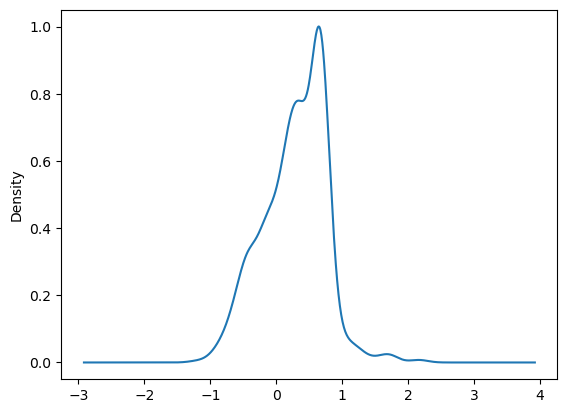

In [11]:
az.summary(posterior_chain)["mean"].plot(kind="kde")

In [12]:
df_posterior_chain = ut.get_summary(posterior_chain)
df_posterior_chain

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,var_name,var_idx
0,1.279,1.263,0.233,3.350,0.624,0.479,4.0,15.0,3.44,a,"0, 0]"
1,0.495,0.460,0.162,1.353,0.198,0.148,4.0,4.0,3.27,a,"1, 0]"
2,0.448,0.450,0.029,1.391,0.209,0.158,4.0,4.0,3.49,a,"2, 0]"
3,0.431,0.407,0.104,1.307,0.188,0.142,4.0,12.0,3.25,a,"3, 0]"
4,0.595,0.395,0.162,1.284,0.180,0.136,5.0,11.0,2.65,a,"4, 0]"
...,...,...,...,...,...,...,...,...,...,...,...
787,0.454,0.727,-0.772,2.003,0.284,0.224,7.0,18.0,2.14,z_pr,"93, 0]"
788,0.155,0.997,-1.401,2.116,0.361,0.266,9.0,37.0,1.42,z_pr,"94, 0]"
789,-0.441,0.985,-1.753,1.473,0.329,0.241,9.0,48.0,1.38,z_pr,"95, 0]"
790,0.588,0.907,-0.731,2.459,0.392,0.294,6.0,15.0,1.84,z_pr,"96, 0]"


In [13]:
r_hat = ut.get_rhat(df_posterior_chain)
r_hat

,0,1,2,3,4,5,6,7,8,9,...,782,783,784,785,786,787,788,789,790,791
r_hat,3.44,3.27,3.49,3.25,2.65,3.76,2.63,3.64,3.33,3.07,...,1.37,1.22,1.56,1.59,1.43,2.14,1.42,1.38,1.84,2.07


/home/rkm160630/anaconda3/envs/ds3/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/rkm160630/anaconda3/envs/ds3/lib/python3.11/site-packages/arviz/stats/density_utils.py:980: RuntimeWarning: divide by zero encountered in divide
  hist_dens = hist / (hist.sum() * np.diff(bin_edges))
/home/rkm160630/anaconda3/envs/ds3/lib/python3.11/site-packages/arviz/stats/density_utils.py:980: RuntimeWarning: invalid value encountered in divide
  hist_dens = hist / (hist.sum() * np.diff(bin_edges))
/home/rkm160630/anaconda3/envs/ds3/lib/python3.11/site-packages/arviz/stats/density_utils.py:699: RuntimeWarning: divide by zero encountered in divide
  f = grid_counts / bin_width / len(x)
/home/rkm160630/anaconda3/envs/ds3/lib/python3.11/site-packages/arviz/stats/density_utils.py:699: RuntimeWarning: invalid value encountered in divi

OverflowError: cannot convert float infinity to integer

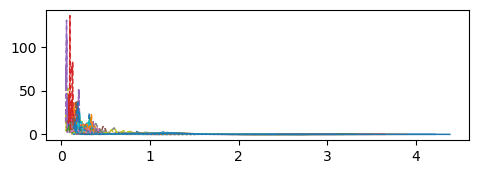

In [14]:
az.plot_trace(posterior_chain)

In [ ]:
#posterior_chain = posterior_chain.sel(chain=[0,2,3])

In [ ]:
az.summary(posterior_chain)

In [ ]:
r_hat.T.plot(kind="kde")

In [ ]:
#az.plot_trace(posterior_chain)

In [ ]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

In [ ]:
v_c_ch.plot(kind="kde")

In [ ]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

In [ ]:
a_c_ch.fillna(0).plot(kind="kde")

In [ ]:
z_c_ch = ut.get_chains_for_param(posterior_chain,"z")
z_c_ch

In [ ]:
z_c_ch.fillna(0).plot(kind="kde")

In [ ]:
ter_c_ch = ut.get_chains_for_param(posterior_chain,"t_er")
ter_c_ch

In [ ]:
ter_c_ch.fillna(0).plot(kind="kde")